> **License & Attribution**  
> This notebook is a derivative of [LLMs-from-scratch](https://github.com/rasbt/LLMs-from-scratch)  
> by Sebastian Raschka, licensed under the Apache License 2.0.  
> Modifications made by [enhennnn].  
>  
> SPDX-License-Identifier: Apache-2.0  
> For the full license text, see the [LICENSE](LICENSE) file in this repository

## 目录

1. 回顾之前的模型
2. 损失函数：交叉熵和困惑度
3. 计算训练集和验证集的损失
4. 训练模型
5. 增加decoding的随机性
6. 保存与导入模型参数
7. 从OpenAI中导入参数

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/mental-model--0.webp" width=400px>

&nbsp;
## 1. 回顾之前的模型

In [12]:
import torch
from GPTmodel import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();

In [13]:
import tiktoken
from GPTmodel import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    # 在0号位置增加一个数值为1的维度，作为batch维度，契合模型的输入格式
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    # 移除0号位置的维度
    flat = token_ids.squeeze(0)
    # 将tensor转为list
    return tokenizer.decode(flat.tolist())

In [14]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


&nbsp;
## 2. 损失函数：交叉熵和困惑度

In [15]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

In [16]:
# 得到logits和probas
model = GPTModel(GPT_CONFIG_124M)
with torch.no_grad():
    logits = model(inputs)
probas = torch.softmax(logits, dim = -1)
print("probas: ", probas)
print("probas shape: ", probas.shape)


probas:  tensor([[[8.0122e-06, 1.5223e-05, 2.0279e-05,  ..., 1.9716e-05,
          6.8389e-06, 3.1622e-05],
         [1.0178e-05, 1.8387e-05, 9.2599e-06,  ..., 6.9709e-06,
          1.7784e-05, 1.2633e-05],
         [8.0861e-06, 1.0148e-05, 2.4334e-05,  ..., 1.2254e-05,
          8.8312e-06, 2.2144e-05]],

        [[1.4894e-05, 1.4330e-05, 1.7850e-05,  ..., 2.2532e-05,
          1.9515e-05, 3.1714e-05],
         [8.8124e-06, 9.1939e-06, 2.0327e-05,  ..., 2.0754e-05,
          1.2410e-05, 2.1241e-05],
         [1.1692e-05, 9.0302e-06, 1.2065e-05,  ..., 3.2464e-05,
          7.1816e-06, 2.7122e-05]]])
probas shape:  torch.Size([2, 3, 50257])


In [17]:
# 这个cell只是检查一下结果
# 得到最大概率的token ID
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

# 将正确答案的token ID转为token，来自target
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
# 将模型的答案的token ID转为token
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Token IDs:
 tensor([[[24882],
         [22418],
         [ 9639]],

        [[26385],
         [ 2073],
         [24333]]])
Targets batch 1:  effort moves you
Outputs batch 1: orously Munich loaded


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/cross-entropy.webp?123" width=400px>

In [18]:
# 找出当前targets的token的概率，target probabilities
# 当前token ID为[3626, 6100, 345]的概率，我们希望这个概率接近1
# " effort moves you"     
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)
# 当前token ID为[1107,  588, 11311]的概率，我们希望这个概率接近1
# " really like chocolate"
text_idx = 1    
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

# 将两个target_probas拼接起来，以自然常数e为底，取对数，log probabilities
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

# 求对数之和的平均值
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

# 取负值
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

Text 1: tensor([3.1669e-05, 2.0789e-05, 2.6520e-05])
Text 2: tensor([4.5286e-06, 3.3238e-05, 3.5988e-05])
tensor([-10.3602, -10.7811, -10.5376, -12.3051, -10.3118, -10.2323])
tensor(-10.7547)
tensor(10.7547)


In [19]:
# 使用torch中封装好的交叉熵函数实现上述步骤

# 首先观察logits和targets的形状
print(logits.shape)
print(targets.shape)

# 将logtis和targets展平
logits_flat = logits.flatten(0,1)
targets_flat = targets.flatten()
print(logits_flat.shape)
print(targets_flat.shape)

# 输入为logts和targets token ID
# 自动对logits做softmax、找到target probabilities与对数计算
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

torch.Size([2, 3, 50257])
torch.Size([2, 3])
torch.Size([6, 50257])
torch.Size([6])
tensor(10.7547)


- 困惑度就是交叉熵损失的指数值

In [20]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(46849.1094)


&nbsp;
## 3. 计算训练集和验证集的损失

In [21]:
# 准备好训练资料
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

tokenizer = tiktoken.get_encoding("gpt2")

# 检查文本中，单词和token数量
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("charateres:", total_characters)
print("tokens:", total_tokens)

charateres: 20479
tokens: 5145


In [22]:
from GPTmodel import create_dataloader_v1

torch.manual_seed(123)

# 划分训练集和验证集
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

# 初始化Dataloader,是一个可迭代对象
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

- 检查数据有没有正确导入

In [23]:
# 方法一，统计Dataloader的数据中，每一个batch的形状
# 在这里有9个batch，batch_size=2，seq_len=256
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [24]:
# 方法二，统计token的数目
# 在PyTorch中，调用.numel()方法会返回张量中所有元素的总数，无论张量的形状或维度如何
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


- 计算在训练集或验证集上的损失

In [25]:
# 一个batch的loss
def calc_loss_batch(input_batch, target_batch, model, device):
    # 将input_batch和target_batch放在同一设备上
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)

    # 将input输入到模型中，得到logtis
    logits = model(input_batch)

    # 用交叉熵函数对于logits进行计算,交叉熵的输入形状为二维
    # logits的shape：(batch_size, seq_len, hidden_dim) -> (batch_size*seq_len, hidden_dim)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

# 所有batch的loss
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.

    # len(data_loader)返回batch数量
    if len(data_loader) == 0:
        return float("nan")
    # 这里可指定处理前n个batch的数据，如果没有指定，则处理所有batch
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
    # 这里可指定处理前n个batch的数据
    # 如果指定数量多于实际数量，则处理所有batch
    # 如果指定数量少于实际数量，则处理指定数量的batch
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break

    return total_loss / num_batches

In [26]:
torch.manual_seed(123) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 单纯计算一下目前初始数据的loss
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.983978695339626
Validation loss: 10.992042541503906


&nbsp;
## 4. 训练模型

- 在这里只是简单训练

    还可以增加：学习率预热、余弦退火和梯度裁剪等


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/train-steps.webp" width=300px>

In [27]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
   
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        # 一次处理一个batch
        for input_batch, target_batch in train_loader:
            # 处理一个batch前，初始化梯度为0
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            # update更新梯度
            optimizer.step() 

            # 记录处理token数量和global_step
            tokens_seen += input_batch.numel()
            global_step += 1

            # 每经过eval_freq步就进行验证
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
        
        # 绘图
        generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        # 在这里只取前eval_iter个batch计算loss
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " ")) 
    model.train()

In [28]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)
model.to(device)

# AdamW优化,学习率为0.004,动量衰减是0.1
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.816, Val loss 9.925
Ep 1 (Step 000005): Train loss 8.067, Val loss 8.334
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.625, Val loss 7.049
Ep 2 (Step 000015): Train loss 6.050, Val loss 6.601
Every effort moves you, and,, and,,,,,,, and,.                                   
Ep 3 (Step 000020): Train loss 5.582, Val loss 6.476
Ep 3 (Step 000025): Train loss 5.474, Val loss 6.402
Every effort moves you, and to the to the of the of the, and, and. G. Gis, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,
Ep 4 (Step 000030): Train loss 5.054, Val loss 6.327
Ep 4 (Step 000035): Train loss 4.776, Val loss 6.322
Every effort moves you a the picture.  "I had been the picture.   ", and I had been the of the of the picture. I had been the picture. I had been the picture to the picture and I had been. "
Ep 5 (Step 000040): Train loss 4.153, Val loss 6.194
Every effort moves you know

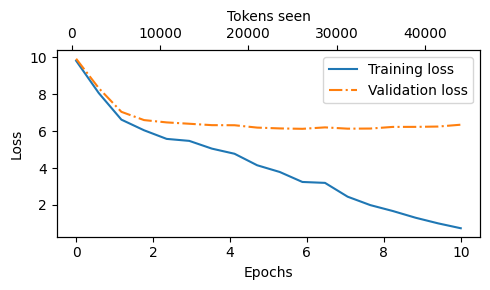

In [29]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True)) 
    ax2 = ax1.twiny() 
    ax2.plot(tokens_seen, train_losses, alpha=0) 
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)


&nbsp;
## 5. 增加decoding的随机性

- 现在得到的结果都是比较稳定的，为了增加随机性，采用两种decoding策略：`温度缩放`和`top-k采样`

In [30]:
model.to("cpu")
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




In [31]:
# 接下来，温度缩放和top-k使用的sample
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 
inverse_vocab = {v: k for k, v in vocab.items()}
next_token_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])
probas = torch.softmax(next_token_logits, dim=0)

- 温度缩放

In [32]:
# 选最大概率的token，结果通常固定
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id], '\n')

forward 



In [33]:
#torch.manual_seed(123)

# multionomial对probas的概率随机取样，不一定取到概率最大的token
# 增加了随机性
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id], '\n')

# 重复multionomial操作1000次
def print_sampled_tokens(probas):
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    # bincount统计sample中每个数字出现了几次
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")
print_sampled_tokens(probas)

forward 

53 x closer
1 x every
0 x effort
585 x forward
1 x inches
1 x moves
0 x pizza
357 x toward
2 x you


In [34]:
# 引入温度，通过温度控制logits，再经过softmax从而改变probas分布，multinomial就能取到不同token
# 当温度值大于 1 时，softmax 输出的概率分布会更加均匀，从而增加生成文本的多样性。
# 当温度值小于 1 时，softmax 输出的概率分布会更加集中（更陡峭或更尖锐），从而倾向于选择概率更高的 token，减少随机性。
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

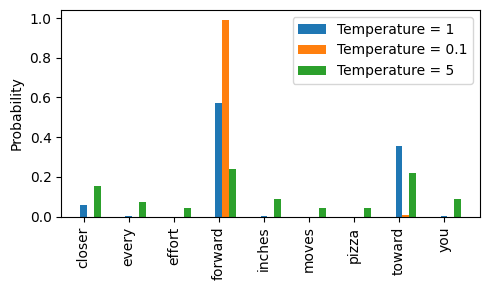

In [35]:
# 可视化，当温度取不同值时probas的分布
temperatures = [1, 0.1, 5] 
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

- top-k采样

    方法一：利用前k个token的logit值，将不是top-k的token遮掩

    方法二：利用前k个token的位置，将top-k个值加入-inf组成的tensor

In [36]:
top_k = 3

# 同样是对logits操作，首先找出前k个token的logit值，top_logits
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)

# 将不是top-k的token遮掩
# 若logit值小于top_logits值，将其logit值改为-inf
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")), 
    other=next_token_logits
    )
print("new_logits:", new_logits)

# 将遮掩后的logits重新归一化
topk_probas = torch.softmax(new_logits, dim=0)
print("topk_probas:", topk_probas)

Top logits: tensor([6.7500, 6.2800, 4.5100])
new_logits: tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
topk_probas: tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [37]:
top_k = 3

# 同样是对logits操作，首先找出前k个token的位置，top_pos
_, top_pos = torch.topk(next_token_logits, top_k)
print("Top positions:", top_pos)

# 创建一个next_token_logits.shape的tensor，全为-inf
new_logits = torch.full_like(next_token_logits, -torch.inf)   
print("new_logits:", new_logits)

# 将top-k个值加入该tensor
new_logits[top_pos] = next_token_logits[top_pos]
print("new_logits", new_logits)

# 将遮掩后的logits重新归一化
topk_probas = torch.softmax(new_logits, dim=0)
print("topk_probas:", topk_probas)

Top positions: tensor([3, 7, 0])
new_logits: tensor([-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf])
new_logits tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
topk_probas: tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


- 结合`温度缩放`和`top-k采样`，改进`generate_text_simple()`函数

In [38]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # top-k部分，得到新logits
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)
        # 温度缩放部分，由处理后的logits得到probs，再随机取样得到token ID
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)  # (batch_size, vocab_size)
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)
        # eos_id对应结束token
        if idx_next == eos_id:  
            break

        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [39]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"
His up surprise. It is to have been an object for enough


&nbsp;
## 6. 保存与导入模型参数

In [40]:
# 保存训练好的模型参数
torch.save(model.state_dict(), "model.pth")

In [41]:
# 导入训练好的模型参数
from GPTmodel import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}
model = GPTModel(GPT_CONFIG_124M)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval(); 

&nbsp;
## 7. 从OpenAI中导入参数

In [42]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


In [43]:
print("Settings:", settings)

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


In [44]:
print("Parameter dictionary keys:", params.keys())

Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [45]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


In [46]:
from GPTmodel import GPTModel

# 将前面演示的超参数更改为实际GPT2的超参数
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# 应对不同规模的GPT2，在这里使用gpt2-small(124M)模型
model_name = "gpt2-small (124M)" 
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

In [47]:
# 将下载的参数导入实例化的gpt模型中
# 导入前，比较两者对应参数的形状是否一致
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [ ]:
import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_weights_into_gpt(gpt, params):
    # 载入词汇表和位置编码
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    # gpt2-small有12个transformer blocks
    for b in range(len(params["blocks"])):
        # 载入Wq、Wk、Wv的权重w、偏置b 和 输出层的w、b
        q_w, k_w, v_w = np.split((params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split((params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(gpt.trf_blocks[b].att.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(gpt.trf_blocks[b].att.out_proj.bias, params["blocks"][b]["attn"]["c_proj"]["b"])

        # 载入全连接层的权重w、偏置b
        # layers[0]：全连接层，layers[1]：激活函数，layers[2]：全连接层
        gpt.trf_blocks[b].ff.layers[0].weight = assign(gpt.trf_blocks[b].ff.layers[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(gpt.trf_blocks[b].ff.layers[0].bias, params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(gpt.trf_blocks[b].ff.layers[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(gpt.trf_blocks[b].ff.layers[2].bias, params["blocks"][b]["mlp"]["c_proj"]["b"])

        # 载入归一化层的缩放g、偏置b
        gpt.trf_blocks[b].norm1.scale = assign(gpt.trf_blocks[b].norm1.scale, params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(gpt.trf_blocks[b].norm1.shift, params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(gpt.trf_blocks[b].norm2.scale, params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(gpt.trf_blocks[b].norm2.shift, params["blocks"][b]["ln_2"]["b"])

    # 载入全局输出层的缩放g、偏置b和输出头的权重矩阵
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

load_weights_into_gpt(gpt, params)
gpt.to(device);

In [51]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the hand can go until the end of your turn unless something happens

This would remove you from a battle
